In [5]:
import yfinance as yf
import pandas as pd

etfs = ["SCHD", "QQQ", "JEPQ"]

price_data = {}
div_data = {}

for etf in etfs:
    ticker = yf.Ticker(etf)
    
    df = ticker.history(start="2020-01-01")
    if df.empty:
        continue

    price_data[etf] = df["Close"]

    div = ticker.dividends
    div_data[etf] = div

price_df = pd.DataFrame(price_data)

## 📊 Price-Based Return Analysis

In this step, we calculate and compare the price-based returns of selected ETFs.

This analysis focuses only on price changes and does not include dividends.

In [6]:
# Daily returns
returns_df = price_df.pct_change().dropna()

returns_df.head()

,SCHD,QQQ,JEPQ
Date,,,
2022-05-05 00:00:00-04:00,-0.024870,-0.050364,-0.023780
2022-05-06 00:00:00-04:00,0.002342,-0.011981,-0.013432
2022-05-09 00:00:00-04:00,-0.013501,-0.039127,-0.030278
2022-05-10 00:00:00-04:00,-0.005001,0.012149,0.007188
2022-05-11 00:00:00-04:00,-0.007935,-0.029658,-0.024406


## 📈 Cumulative Returns

To better understand long-term performance, cumulative returns are calculated.

In [7]:
# Cumulative returns
cumulative_returns = (1 + returns_df).cumprod()

cumulative_returns.head()

,SCHD,QQQ,JEPQ
Date,,,
2022-05-05 00:00:00-04:00,0.975130,0.949636,0.976220
2022-05-06 00:00:00-04:00,0.977414,0.938259,0.963108
2022-05-09 00:00:00-04:00,0.964218,0.901547,0.933947
2022-05-10 00:00:00-04:00,0.959396,0.912500,0.940660
2022-05-11 00:00:00-04:00,0.951783,0.885437,0.917702


## 📉 Visualization

The cumulative returns of each ETF are plotted to compare performance over time.

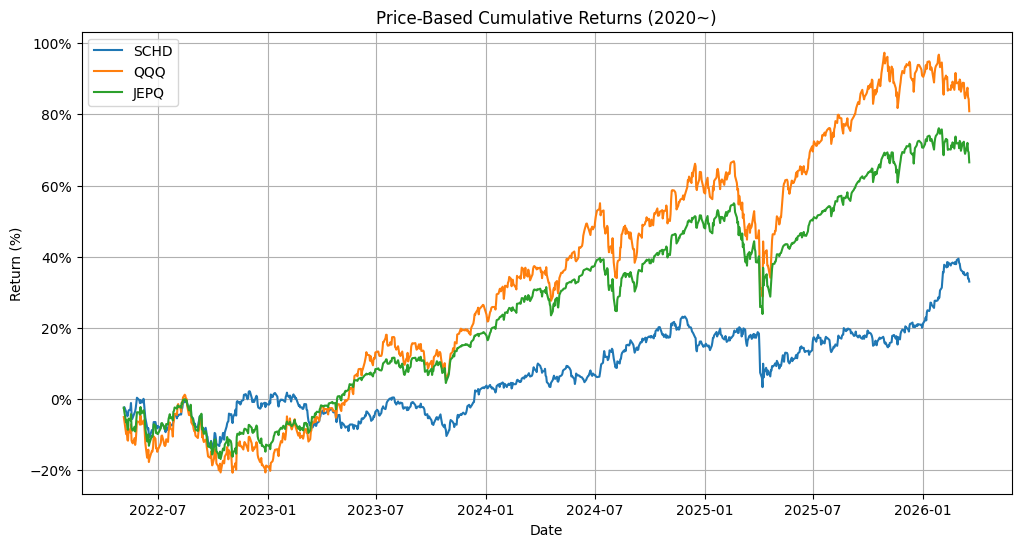

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(12,6))

for etf in cumulative_returns.columns:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[etf] - 1,
        label=etf
    )

plt.title("Price-Based Cumulative Returns (2020~)")
plt.xlabel("Date")
plt.ylabel("Return (%)")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend()
plt.grid(True)
plt.savefig("images/price_return.png")
plt.show()

## 🔍 Key Observations

- QQQ shows the highest growth among the ETFs, reflecting strong performance in the technology sector  
- SCHD demonstrates more stable and moderate growth  
- JEPQ shows relatively lower price appreciation compared to QQQ  
- The analysis starts from 2022, as JEPQ was launched later and earlier data contains missing values  

This analysis highlights how focusing only on price returns can lead to different interpretations of ETF performance, especially for income-oriented ETFs.